In [1]:
!pip uninstall gensim -y
!pip uninstall numpy -y

Found existing installation: gensim 4.3.3
Uninstalling gensim-4.3.3:
  Successfully uninstalled gensim-4.3.3
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4


In [1]:
!pip install numpy
!pip install gensim

  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.7 MB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.0
    Uninstalling numpy-2.3.0:
      Successfully uninstalled numpy-2.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.


In [27]:
import nltk
nltk.download('punkt')



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [28]:
import re
import nltk
import numpy as np
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from sklearn. manifold import TSNE
from gensim.models import word2vec
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [6]:
! pip install opendatasets


In [8]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/khalidryder777/500k-chatgpt-tweets-jan-mar-2023")

Dataset URL: https://www.kaggle.com/datasets/khalidryder777/500k-chatgpt-tweets-jan-mar-2023


100%|██████████| 47.5M/47.5M [00:00<00:00, 1.13GB/s]

In [9]:
df = pd.read_csv("/content/500k-chatgpt-tweets-jan-mar-2023/Twitter Jan Mar.csv")
df.head()

,date,id,content,username,like_count,retweet_count
0,2023-03-29 22:58:21+00:00,1641213230730051584,"Free AI marketing and automation tools, strate...",RealProfitPros,0.0,0.0
1,2023-03-29 22:58:18+00:00,1641213218520481805,@MecoleHardman4 Chat GPT says it’s 15. 😂,AmyLouWho321,0.0,0.0
2,2023-03-29 22:57:53+00:00,1641213115684536323,https://t.co/FjJSprt0te - Chat with any PDF!\n...,yjleon1976,0.0,0.0
3,2023-03-29 22:57:52+00:00,1641213110915571715,"AI muses: ""In the court of life, we must all f...",ChatGPT_Thinks,0.0,0.0
4,2023-03-29 22:57:26+00:00,1641213003260633088,Most people haven't heard of Chat GPT yet.\nFi...,nikocosmonaut,0.0,0.0


In [10]:
df.shape

(500036, 6)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500036 entries, 0 to 500035
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date           500036 non-null  object 
 1   id             500030 non-null  object 
 2   content        500030 non-null  object 
 3   username       500002 non-null  object 
 4   like_count     499974 non-null  float64
 5   retweet_count  499974 non-null  float64
dtypes: float64(2), object(4)
memory usage: 22.9+ MB


In [16]:
article_text = " "
for i in range (500):
  # print(df["content"][i])
  article_text += str(df["content"][i])


In [30]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [34]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Text cleaning

In [36]:
# convert the data to uniform case
processed_article = article_text.lower()
processed_article = re.sub('[^a-zA-Z]', ' ', processed_article)
processed_article = re.sub(r'\s+', ' ', processed_article)

# Download the required punkt_tab resource
import nltk
nltk.download('punkt_tab')

#Preparing the dataset
all_sentences = nltk.sent_tokenize(processed_article)

all_words = [nltk.word_tokenize(sent) for sent in all_sentences]

#Removing Stop words
for i in range(len(all_words)):
  all_words[i] = [w for w in all_words[i] if w not in stopwords.words('english')]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Declare model for word2vec

In [38]:
model = word2vec.Word2Vec(all_words, min_count=2, workers=4)

#Building vocabulary
model.build_vocab(all_words)

# Train the model
model.train(all_words, total_examples=model.corpus_count, epochs=model.epochs)

(22795, 42745)

In [40]:
# we use wv to get the vector output for a given word
demo_wv_vector = model.wv["ai"]
demo_wv_vector

array([-0.3573561 ,  0.4858576 ,  0.13091327,  0.07940957,  0.09236518,
       -0.7308068 ,  0.19122946,  1.0287124 , -0.44175658, -0.28916383,
       -0.46995395, -0.5676722 , -0.18541117,  0.22338103,  0.04979884,
       -0.6349832 ,  0.275631  , -0.3876972 , -0.4046351 , -0.8829824 ,
        0.44275177,  0.24386232,  0.4204127 , -0.21275273, -0.10662569,
       -0.11550723, -0.5250846 , -0.2898442 , -0.4543613 ,  0.21867971,
        0.597751  , -0.0660103 ,  0.08849873, -0.51379687, -0.23180327,
        0.6443719 ,  0.0484924 , -0.30449137, -0.5265622 , -0.5813913 ,
        0.12138096, -0.3546741 , -0.07852518,  0.11413073,  0.3057024 ,
       -0.28154302, -0.16419542, -0.20709933,  0.42972815,  0.1798566 ,
        0.24508493, -0.5080551 , -0.13370663, -0.12969619, -0.36454734,
        0.08075564,  0.34433848, -0.14547332, -0.42860663,  0.10761873,
        0.14125209,  0.1184468 , -0.01779174, -0.18018912, -0.5227241 ,
        0.43244562,  0.36247036,  0.42561188, -0.6908582 ,  0.39

In [41]:
demo_wv_vector.shape

(100,)

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


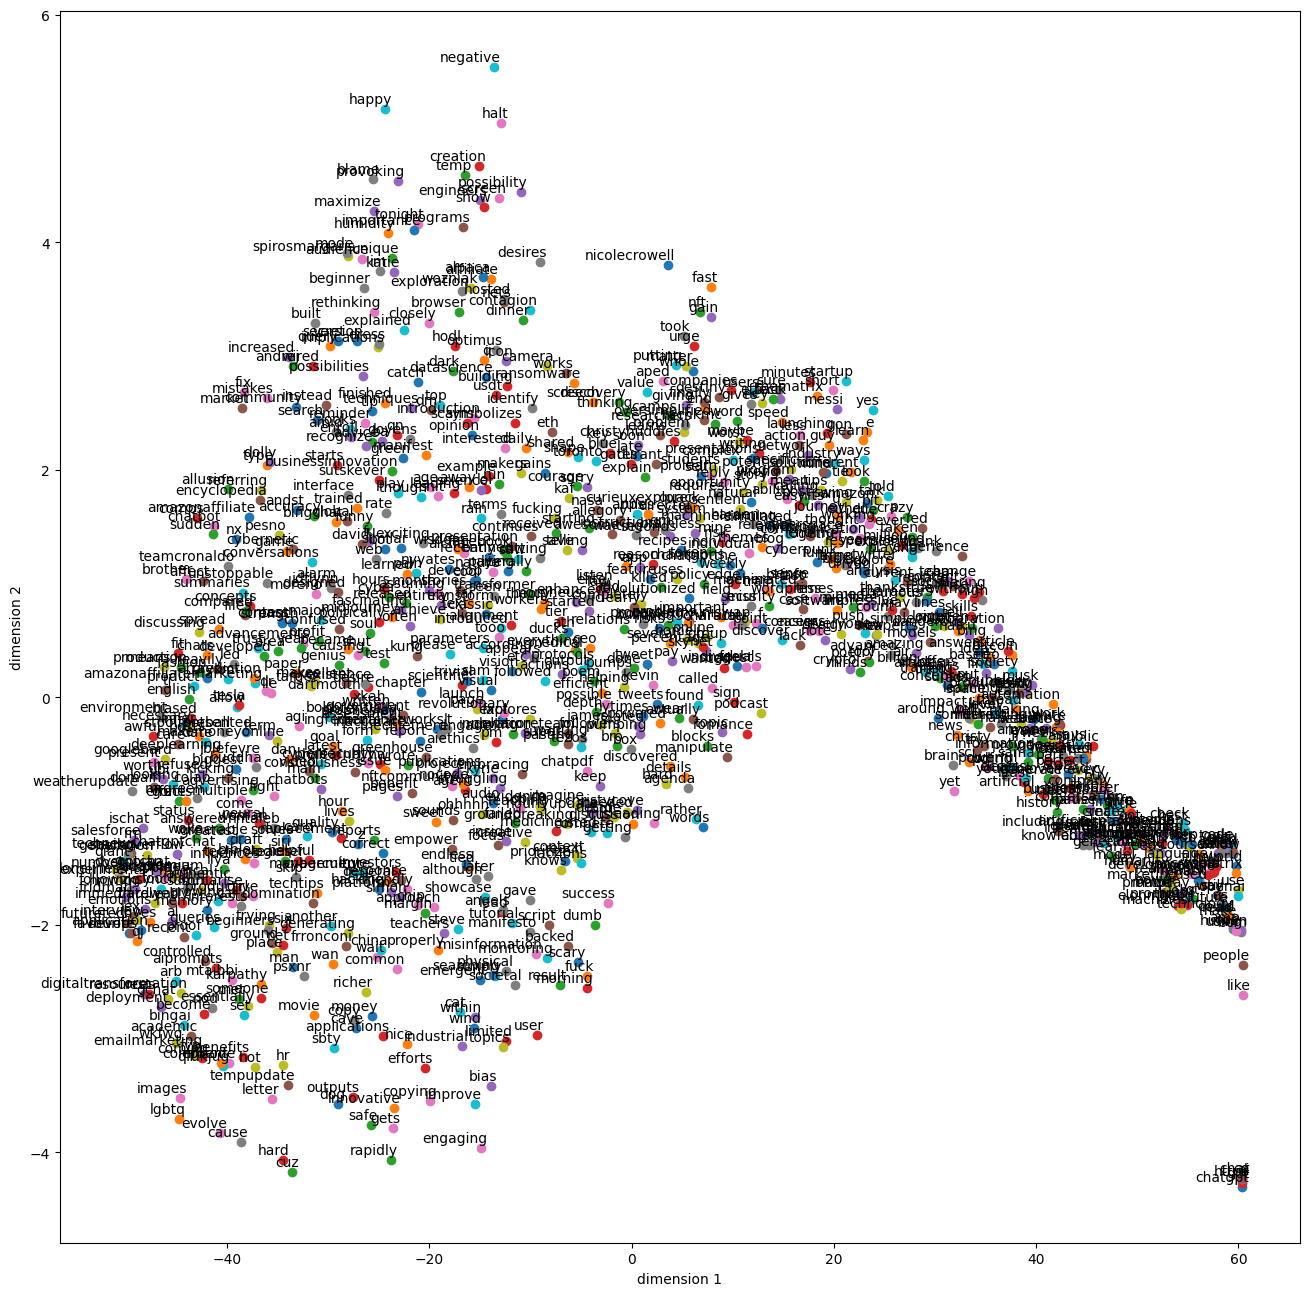

In [51]:
def tsne_plot():
    labels = []
    tokens = []

    # Extracting words and their vectors from our trained model
    for word in model.wv.index_to_key:
        tokens.append(model.wv[word])
        labels.append(word)

    # Convert tokens to a NumPy array
    tokens_array = np.array(tokens)

    # Train t-SNE
    tsne_model = TSNE(perplexity=45, n_components=2, init='pca', n_iter=2500, random_state=23)
    # Pass the NumPy array to fit_transform
    new_values = tsne_model.fit_transform(tokens_array)

    x = []
    y = []

    for value in new_values:
        x.append(value[0])
        y.append(value[1])

    plt.figure(figsize=(16, 16))
    for i in range(len(x)):
        plt.scatter(x[i],y[i])
        plt.annotate(labels[i],
                     xy=(x[i], y[i]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
        plt.xlabel("dimension 1")
        plt.ylabel("dimension 2")
    plt.show()

# Call the corrected function
tsne_plot()

In [47]:
# demo output
model.wv.most_similar("ai")

[('chatgpt', 0.9998157620429993),
 ('gpt', 0.9997925758361816),
 ('https', 0.9997488260269165),
 ('chat', 0.999730110168457),
 ('co', 0.9997159838676453),
 ('like', 0.9995889663696289),
 ('people', 0.999573826789856),
 ('using', 0.9995696544647217),
 ('bcm', 0.9995446801185608),
 ('human', 0.9995271563529968)]

In [48]:
model.wv.most_similar('openai')

[('chatgpt', 0.9995737075805664),
 ('https', 0.9995318651199341),
 ('ai', 0.9995061755180359),
 ('gpt', 0.9994936585426331),
 ('chat', 0.9994397163391113),
 ('human', 0.9994303584098816),
 ('using', 0.9994131326675415),
 ('co', 0.999392032623291),
 ('amp', 0.9993572235107422),
 ('people', 0.9993173480033875)]